##  Persistant memory

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter,CharacterTextSplitter
from langchain_community.document_loaders import TextLoader,PyMuPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma,FAISS
import fitz  
import warnings
from langchain_community.tools.tavily_search import TavilySearchResults
#utility
import numpy as np
from typing import List,Dict,Any
from sentence_transformers import SentenceTransformer

from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.runnables import (RunnablePassthrough,RunnableMap)
from langchain_core.output_parsers import StrOutputParser
import os
import numpy as np
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_core.documents import Document

from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains.retrieval import create_retrieval_chain
from langchain_classic.document_loaders import WikipediaLoader
from PIL import Image
import torch
from transformers import CLIPProcessor,CLIPModel
import base64
import io
from langchain.messages import SystemMessage,HumanMessage,AIMessage,AnyMessage
from pydantic import BaseModel,Field
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware,HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage,SystemMessage
from langchain.tools import tool
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display
from langgraph.graph import MessagesState
## Reducers
from typing import Annotated
from typing import Literal
from langgraph.graph.message import add_messages
import random
from  dataclasses import dataclass
from pydantic import BaseModel,Field
from pprint import pprint
from langgraph.graph.message import add_messages
from typing import Annotated
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langgraph.checkpoint.memory import MemorySaver
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_groq import ChatGroq
warnings.filterwarnings("ignore")
from dotenv import load_dotenv
load_dotenv()
import bs4

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"

)
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0

)
llm

C:\Users\kanha\AppData\Local\Temp\ipykernel_10092\1310865908.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader,PyMuPDFLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002298BAE8ED0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002298A971E90>, model_name='llama-3.3-70b-versatile', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
import bs4

In [9]:
### Build Index


from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

### from langchain_cohere import CohereEmbeddings

# Set embeddings


# Docs to index
urls = "https://lilianweng.github.io/posts/2023-06-23-agent/",

# Load
docs = WebBaseLoader(web_paths=(urls),
                     bs_kwargs=dict(
                         parse_only=bs4.SoupStrainer(
                             class_=("post-content","post-title","post-header")
                         )
                     )).load() 


# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=50
)
doc_splits = text_splitter.split_documents(docs)

# Add to vectorstore
vectorstore=FAISS.from_documents(
    documents=doc_splits,
    embedding=embeddings
)


retriever=vectorstore.as_retriever()

In [10]:
retriever

VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x000002298E085CD0>, search_kwargs={})

In [11]:
@tool()
def retriev(query:str):
    """Retrieve the information relatedto the query"""
    retrieved_docs=vectorstore.similarity_search(query=query,k=2)
    serialized="\n\n".join(
        (f"Source:{doc.metadata}\n content:{doc.page_content}")
        for doc in retrieved_docs
    )
    return serialized,retrieved_docs


In [14]:
from langgraph.graph import MessagesState

In [16]:
def query_or_respond(state:MessagesState):
    """Generate tool call for retrieval or respond"""
    llm_eith_tools=llm.bind_tools([retriev])
    response=llm_eith_tools.invoke(state['messages'])
    return {"messages":[response]}


In [17]:
tools=ToolNode([retriev])
tools

tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'retriev': StructuredTool(name='retriev', description='Retrieve the information relatedto the query', args_schema=<class 'langchain_core.utils.pydantic.retriev'>, func=<function retriev at 0x000002298ECB85E0>)}, _injected_args={'retriev': _InjectedArgs(state={}, store=None, runtime=None, all_injected_keys=set(), _optional_state_args=set())}, _handle_tool_errors=<function _default_handle_tool_errors at 0x000002298A52A020>, _messages_key='messages', _wrap_tool_call=None, _awrap_tool_call=None)

In [31]:
def generate(state:MessagesState):
    """generate Answer"""
    recent_tool_messages=[]
    for message in reversed(state['messages']):
        if message.type=="tool":
            recent_tool_messages.append(message)
        else:
            break
    tool_messages=recent_tool_messages[::-1]
    doc_content="\n\n".join(doc.content for doc in tool_messages)
    sysytem_messages=(
        "You are asistant for question answeriing"
        "USethe follownig piece of content to answer in deep theory"
        'the question.If you dont know anssay that you'
        "dont know use three max and keep answer deep"
        "\n\n"
        f"{doc_content}"
    )
    conversatinal_message=[
        message
        for message in state["messages"]
        if message.type in ("human","system")
        or (message.type=="ai" and not message.tool_calls)
    ]
    prompt=[SystemMessage(sysytem_messages)]+conversatinal_message
    response=llm.invoke(prompt)
    return {"messages":[response]}


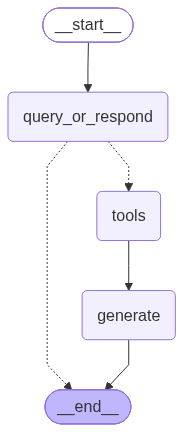

In [32]:
# Build graph
graph_builder = StateGraph(MessagesState)

graph_builder.add_node(query_or_respond)
graph_builder.add_node(tools)
graph_builder.add_node(generate)

graph_builder.set_entry_point("query_or_respond")
graph_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition,
    {END: END, "tools": "tools"},
)
graph_builder.add_edge("tools", "generate")
graph_builder.add_edge("generate", END)

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
graph

In [33]:
config = {"configurable": {"thread_id": "abc123"}}

In [34]:
input_message="Hello"
for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()
    

================================ Human Message =================================

Hello
================================== Ai Message ==================================

I'm here to help. Is there something I can help you with or would you like to retrieve some information using the 'retriev' function?


In [35]:
vectorstore.similarity_search("What is TAsk Decomposition")

[Document(id='66afb95a-6676-4cc1-acfe-ce0b48b0a810', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#\nChain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights into an interpretation of the model’s thinking process.\nTree of Thoughts (Yao et al. 2023) extends CoT by exploring multiple reasoning possibilities at each step. It first decomposes the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure. The search process can be BFS (breadth-first search) or DFS (depth-f

In [36]:
input_message = "What is Task Decomposition?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is Task Decomposition?
================================== Ai Message ==================================
Tool Calls:
  retriev (hn950zp3b)
 Call ID: hn950zp3b
  Args:
    query: Task Decomposition
================================= Tool Message =================================
Name: retriev

('Source:{\'source\': \'https://lilianweng.github.io/posts/2023-06-23-agent/\'}\n content:Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#\nChain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights into an interpretation of the model’

In [25]:
input_message = "Can you look up some common ways of doing it?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Can you look up some common ways of doing it?
================================== Ai Message ==================================
Tool Calls:
  retriev (rcmbsezzy)
 Call ID: rcmbsezzy
  Args:
    query: common task decomposition methods
================================= Tool Message =================================
Name: retriev

('Source:{\'source\': \'https://lilianweng.github.io/posts/2023-06-23-agent/\'}\n content:Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#\nChain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights int

In [37]:
### Conversation History
chat_history=graph.get_state(config).values["messages"]
for message in chat_history:
    message.pretty_print()

================================ Human Message =================================

Hello
================================== Ai Message ==================================

I'm here to help. Is there something I can help you with or would you like to retrieve some information using the 'retriev' function?
================================ Human Message =================================

What is Task Decomposition?
================================== Ai Message ==================================
Tool Calls:
  retriev (hn950zp3b)
 Call ID: hn950zp3b
  Args:
    query: Task Decomposition
================================= Tool Message =================================
Name: retriev

('Source:{\'source\': \'https://lilianweng.github.io/posts/2023-06-23-agent/\'}\n content:Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#\nChain of thought (CoT; Wei et al. 2022) has become a standard prompting techni

In [40]:
from langgraph.prebuilt import create_react_agent
memory = MemorySaver()
agent_executor=create_react_agent(llm,[retriev],checkpointer=memory)

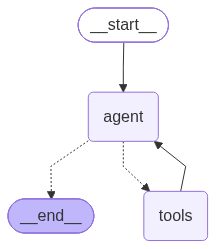

In [41]:
agent_executor

In [42]:
config = {"configurable": {"thread_id": "def234"}}

In [43]:
input_message = (
    "What is the standard method for Task Decomposition?\n\n"
    "Once you get the answer, look up common extensions of that method."
)

In [44]:
for event in agent_executor.stream({"messages": [{"role": "user", "content": input_message}]},
                                   stream_mode="values",
                                   config=config):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

What is the standard method for Task Decomposition?

Once you get the answer, look up common extensions of that method.
================================== Ai Message ==================================
Tool Calls:
  retriev (fjpx8shpd)
 Call ID: fjpx8shpd
  Args:
    query: standard method for Task Decomposition
================================= Tool Message =================================
Name: retriev

('Source:{\'source\': \'https://lilianweng.github.io/posts/2023-06-23-agent/\'}\n content:Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#\nChain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler ste